# Customer Segmentation Analysis

## Business Objective

Identify meaningful customer segments based on purchasing behavior and customer demographics.

## Project Goals

• Analyze customer purchasing behavior
• Perform RFM analysis
• Apply K-Means clustering
• Identify high-value, loyal, occasional, and at-risk customers
• Analyze demographic characteristics of each segment
• Generate targeted business recommendations
• Prepare the final dataset for Power BI visualization

## Technology Stack

Python | Pandas | NumPy | Scikit-learn | Matplotlib | Seaborn | Power BI

## Dataset

Customer Segmentation Complete Dataset

The dataset contains sales transactions together with customer demographic and purchasing information.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Customer_Segmentation_Complete_Dataset (1) (1).xlsx to Customer_Segmentation_Complete_Dataset (1) (1).xlsx


In [ ]:
import os

excel_files = [
    file for file in os.listdir("/content")
    if file.endswith(".xlsx")
]

print("Excel files found:")
print(excel_files)

file_path = "/content/" + excel_files[0]

df = pd.read_excel(file_path)

print("\nDataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Excel files found:
['Customer_Segmentation_Complete_Dataset (1) (1).xlsx']

Dataset loaded successfully
Rows: 7500
Columns: 30


In [ ]:
display(df.head(10))

,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Age,Gender,Income Group,Occupation,Customer Type,Region,City,Segment,Category,Product,Quantity,Unit Price,Discount %,Sales Revenue,Profit,Profit Margin %,Payment Method,Sales Channel,Preferred Channel,Preferred Payment,Order Status,Year,Quarter,Month,Month Name
0,ORD-005278,2024-01-01,2024-01-04,CUST-1839,Priya Patel,31,Female,Lower-Middle,Other,Individual,East,Ranchi,Consumer,Office Supplies,Stapler,4,212.17,0.25,636.51,129.80,0.2039,UPI,Online,Distributor,Cash,Delivered,2024,Q1,1,Jan
1,ORD-002084,2024-01-01,2024-01-02,CUST-1897,Neha Das,60,Male,Middle,Business Owner,Business,South,Hyderabad,Consumer,Office Supplies,Printer Paper,2,465.44,0.05,884.34,190.65,0.2156,Debit Card,Retail Store,Retail Store,UPI,Shipped,2024,Q1,1,Jan
2,ORD-006808,2024-01-01,2024-01-07,CUST-2100,Karthik Iyer,54,Female,Upper-Middle,Finance Professional,Business,South,Chennai,Consumer,Electronics,Laptop,10,57489.46,0.08,528903.03,46647.93,0.0882,Cash,Online,Retail Store,Credit Card,Delivered,2024,Q1,1,Jan
3,ORD-006032,2024-01-01,2024-01-05,CUST-1979,Pooja Kumar,58,Male,Lower-Middle,Student,Business,South,Kochi,Corporate,Office Supplies,Notebook,3,192.37,0.02,565.57,113.08,0.1999,UPI,Online,Online,Debit Card,Delivered,2024,Q1,1,Jan
4,ORD-004350,2024-01-01,2024-01-04,CUST-1189,Vikram Nair,62,Male,Middle,Other,Individual,West,Surat,Small Business,Home Appliances,Electric Kettle,3,1943.99,0.05,5540.37,1115.44,0.2013,Cash,Online,Distributor,Credit Card,Shipped,2024,Q1,1,Jan
5,ORD-002554,2024-01-01,2024-01-07,CUST-1518,Sanjay Gupta,48,Male,Lower-Middle,Teacher,Business,South,Chennai,Small Business,Furniture,Bookshelf,1,4802.68,0.10,4322.41,532.45,0.1232,Net Banking,Retail Store,Online,Debit Card,Delivered,2024,Q1,1,Jan
6,ORD-000364,2024-01-01,2024-01-05,CUST-1335,Arjun Rao,62,Female,Lower-Middle,Business Owner,Individual,West,Pune,Consumer,Electronics,Smartphone,4,26826.12,0.15,91208.81,5566.46,0.0610,Cash,Retail Store,Online,Cash,Delivered,2024,Q1,1,Jan
7,ORD-001191,2024-01-01,2024-01-04,CUST-1448,Arjun Rao,52,Male,Upper-Middle,Engineer,Business,West,Goa,Consumer,Electronics,Laptop,5,54261.64,0.02,265882.04,45409.38,0.1708,UPI,Retail Store,Retail Store,Cash,Delivered,2024,Q1,1,Jan
8,ORD-003409,2024-01-02,2024-01-07,CUST-1971,Rahul Gupta,24,Female,Lower-Middle,Healthcare Professional,Individual,East,Bhubaneswar,Small Business,Home Appliances,Air Conditioner,2,42988.99,0.25,64483.49,9309.36,0.1444,Cash,Retail Store,Retail Store,Cash,Delivered,2024,Q1,1,Jan
9,ORD-003407,2024-01-02,2024-01-04,CUST-2000,Rahul Kumar,58,Male,Middle,Other,Individual,East,Kolkata,Corporate,Electronics,Mouse,4,895.40,0.00,3581.60,591.09,0.1650,Debit Card,Online,Retail Store,Cash,Shipped,2024,Q1,1,Jan


In [ ]:
print("Dataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nData Types")
display(df.dtypes)

Dataset Shape
(7500, 30)

Column Names
['Order ID', 'Order Date', 'Ship Date', 'Customer ID', 'Customer Name', 'Age', 'Gender', 'Income Group', 'Occupation', 'Customer Type', 'Region', 'City', 'Segment', 'Category', 'Product', 'Quantity', 'Unit Price', 'Discount %', 'Sales Revenue', 'Profit', 'Profit Margin %', 'Payment Method', 'Sales Channel', 'Preferred Channel', 'Preferred Payment', 'Order Status', 'Year', 'Quarter', 'Month', 'Month Name']

Data Types


,0
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Customer ID,object
Customer Name,object
Age,int64
Gender,object
Income Group,object
Occupation,object
Customer Type,object


In [ ]:
missing_values = df.isnull().sum()

print("Missing Values")
display(missing_values[missing_values > 0])

print("\nTotal Missing Values:", df.isnull().sum().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values


,0



Total Missing Values: 0

Duplicate Rows: 0


# Data Preparation

The dataset is checked for missing values, duplicate records, incorrect data types, and invalid values before performing customer-level analysis.

The objective is to ensure that the dataset is reliable and suitable for RFM analysis and machine learning.

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print("Order Date Range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

Order Date Range:
2024-01-01 00:00:00 to 2026-07-31 00:00:00


In [ ]:
analysis_date = df["Order Date"].max()

customer_df = df.groupby("Customer ID").agg(
    Customer_Name=("Customer Name", "first"),
    Age=("Age", "first"),
    Gender=("Gender", "first"),
    Income_Group=("Income Group", "first"),
    Occupation=("Occupation", "first"),
    Customer_Type=("Customer Type", "first"),
    Region=("Region", "first"),
    City=("City", "first"),
    Last_Purchase_Date=("Order Date", "max"),
    Frequency=("Order ID", "nunique"),
    Monetary=("Sales Revenue", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Total_Profit=("Profit", "sum"),
    Average_Discount=("Discount %", "mean"),
    Categories_Purchased=("Category", "nunique"),
    Products_Purchased=("Product", "nunique")
).reset_index()

customer_df["Recency"] = (
    analysis_date - customer_df["Last_Purchase_Date"]
).dt.days

customer_df["Average_Order_Value"] = (
    customer_df["Monetary"] / customer_df["Frequency"]
)

customer_df["Profit_Margin"] = (
    customer_df["Total_Profit"] / customer_df["Monetary"]
)

print("Customer-level dataset created")
print("Number of customers:", len(customer_df))

display(customer_df.head())

Customer-level dataset created
Number of customers: 1194


,Customer ID,Customer_Name,Age,Gender,Income_Group,Occupation,Customer_Type,Region,City,Last_Purchase_Date,Frequency,Monetary,Total_Quantity,Total_Profit,Average_Discount,Categories_Purchased,Products_Purchased,Recency,Average_Order_Value,Profit_Margin
0,CUST-1001,Arjun Verma,35,Male,Lower-Middle,IT Professional,Individual,North,Dehradun,2026-02-23,6,138949.87,24,15387.38,0.075000,3,6,158,23158.311667,0.110741
1,CUST-1002,Arjun Patel,31,Male,Middle,Student,Individual,North,Dehradun,2026-07-15,7,643937.90,27,74364.31,0.117143,3,6,16,91991.128571,0.115484
2,CUST-1003,Sneha Gupta,55,Female,Upper-Middle,Student,Business,West,Pune,2026-06-15,7,269672.95,19,35272.46,0.058571,3,6,46,38524.707143,0.130797
3,CUST-1004,Karthik Rao,39,Male,Low,IT Professional,Business,South,Hyderabad,2026-02-17,4,413083.03,18,53369.92,0.030000,3,4,164,103270.757500,0.129199
4,CUST-1005,Manish Mehta,25,Female,Low,Healthcare Professional,Business,North,Dehradun,2026-06-29,6,695369.56,27,125597.61,0.128333,4,6,32,115894.926667,0.180620


# RFM Analysis

RFM analysis evaluates customers using three behavioral measures:

Recency
Measures how recently a customer made a purchase.

Frequency
Measures how frequently a customer purchases.

Monetary
Measures how much revenue a customer generates.

These features help identify differences in customer purchasing behavior and provide a foundation for customer segmentation.

In [ ]:
rfm_summary = customer_df[
    ["Recency", "Frequency", "Monetary"]
].describe()

display(rfm_summary)

,Recency,Frequency,Monetary
count,1194.000000,1194.000000,1194.000000
mean,143.139866,6.281407,211564.256348
std,138.197854,2.465427,160169.887858
min,0.000000,1.000000,263.890000
25%,42.000000,5.000000,88658.612500
50%,102.000000,6.000000,174873.405000
75%,199.750000,8.000000,290261.380000
max,869.000000,16.000000,961790.970000


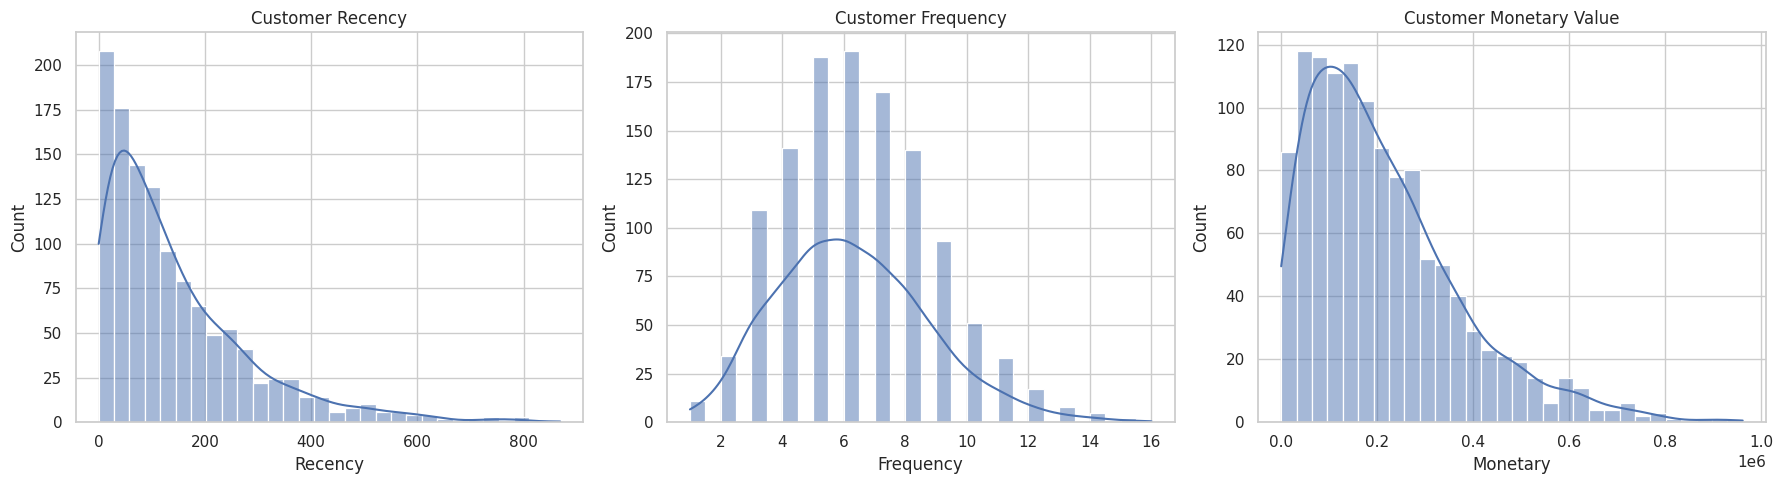

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(customer_df["Recency"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Customer Recency")

sns.histplot(customer_df["Frequency"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Customer Frequency")

sns.histplot(customer_df["Monetary"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Customer Monetary Value")

plt.tight_layout()
plt.show()

# Customer Clustering Methodology

K-Means clustering will be used to group customers with similar purchasing behavior.

The clustering process consists of:

1. Selecting relevant customer behavior features
2. Standardizing the features
3. Testing different numbers of clusters
4. Evaluating cluster quality
5. Selecting an appropriate number of clusters
6. Applying K-Means
7. Profiling and interpreting the resulting customer segments

In [ ]:
clustering_features = [
    "Recency",
    "Frequency",
    "Monetary",
    "Average_Order_Value",
    "Total_Quantity",
    "Total_Profit",
    "Categories_Purchased",
    "Products_Purchased"
]

X = customer_df[clustering_features]

print("Features selected for clustering:")
print(clustering_features)

print("\nFeature matrix shape:")
print(X.shape)

Features selected for clustering:
['Recency', 'Frequency', 'Monetary', 'Average_Order_Value', 'Total_Quantity', 'Total_Profit', 'Categories_Purchased', 'Products_Purchased']

Feature matrix shape:
(1194, 8)


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=clustering_features
)

display(X_scaled_df.head())

,Recency,Frequency,Monetary,Average_Order_Value,Total_Quantity,Total_Profit,Categories_Purchased,Products_Purchased
0,0.107573,-0.114189,-0.453549,-0.438524,0.482514,-0.630470,-0.280538,0.247540
1,-0.920370,0.291590,2.700600,2.377765,0.797392,1.831793,-0.280538,0.247540
2,-0.703199,0.291590,0.362946,0.190191,-0.042283,0.199724,-0.280538,0.247540
3,0.151007,-0.925748,1.258684,2.839270,-0.147242,0.955285,-0.280538,-0.737668
4,-0.804545,-0.114189,3.021842,3.355787,0.797392,3.970762,1.007777,0.247540


In [ ]:
inertia_values = []
silhouette_values = []

k_values = range(2, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertia_values.append(model.inertia_)
    silhouette_values.append(
        silhouette_score(X_scaled, labels)
    )

results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_values,
    "Silhouette Score": silhouette_values
})

display(results)

,K,Inertia,Silhouette Score
0,2,6297.015680,0.296748
1,3,5088.628203,0.236744
2,4,4275.978796,0.240900
3,5,3830.542491,0.238644
4,6,3452.739572,0.228322
5,7,3195.245804,0.203057
6,8,2989.255347,0.191914
7,9,2812.551486,0.197508
8,10,2673.678188,0.196644


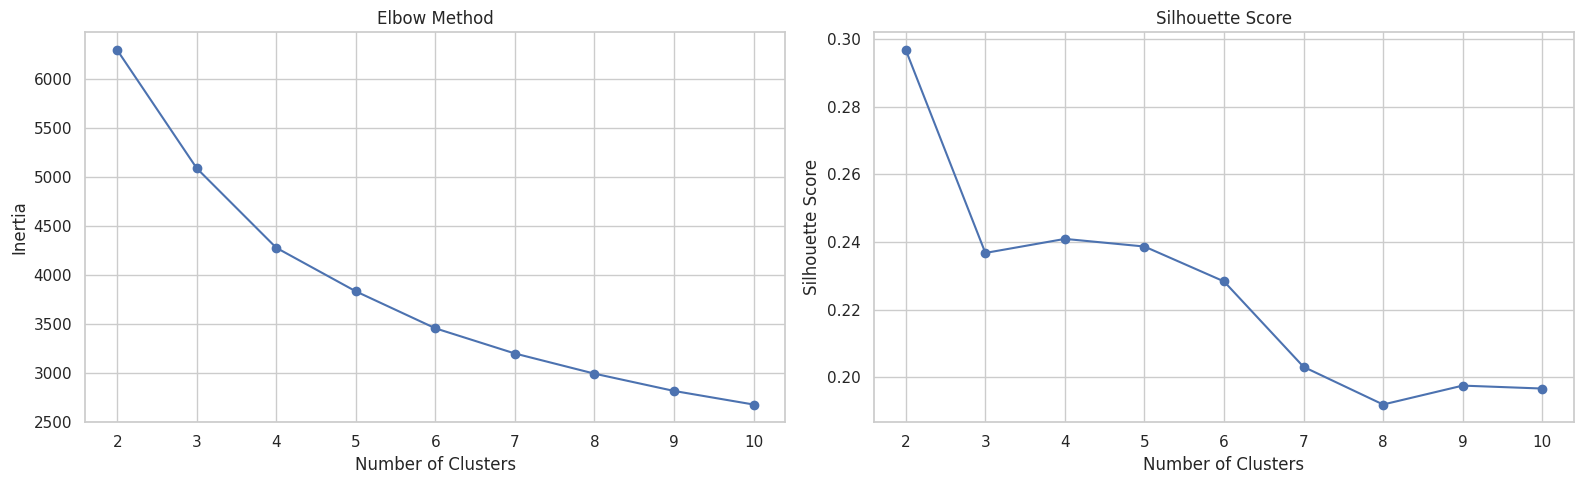

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(k_values, inertia_values, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_values, silhouette_values, marker="o")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [ ]:
best_k = 4

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

customer_df["Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed")

print("\nCustomers in each cluster:")
display(
    customer_df["Cluster"]
    .value_counts()
    .sort_index()
)

K-Means clustering completed

Customers in each cluster:


,count
Cluster,
0,157
1,508
2,232
3,297


In [ ]:
cluster_profile = customer_df.groupby("Cluster").agg(
    Customers=("Customer ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Avg_Order_Value=("Average_Order_Value", "mean"),
    Avg_Profit=("Total_Profit", "mean"),
    Avg_Quantity=("Total_Quantity", "mean"),
    Avg_Categories=("Categories_Purchased", "mean"),
    Avg_Age=("Age", "mean")
).round(2)

display(cluster_profile)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Order_Value,Avg_Profit,Avg_Quantity,Avg_Categories,Avg_Age
Cluster,,,,,,,,,
0,157,135.29,6.38,480020.53,78251.54,69495.14,23.94,3.25,41.61
1,508,111.23,6.33,149438.17,24400.83,21569.94,18.04,3.43,41.44
2,232,77.52,9.61,318947.13,33744.37,46031.62,31.56,3.86,41.31
3,297,253.14,3.54,92034.26,26728.82,12982.51,9.84,2.34,42.07


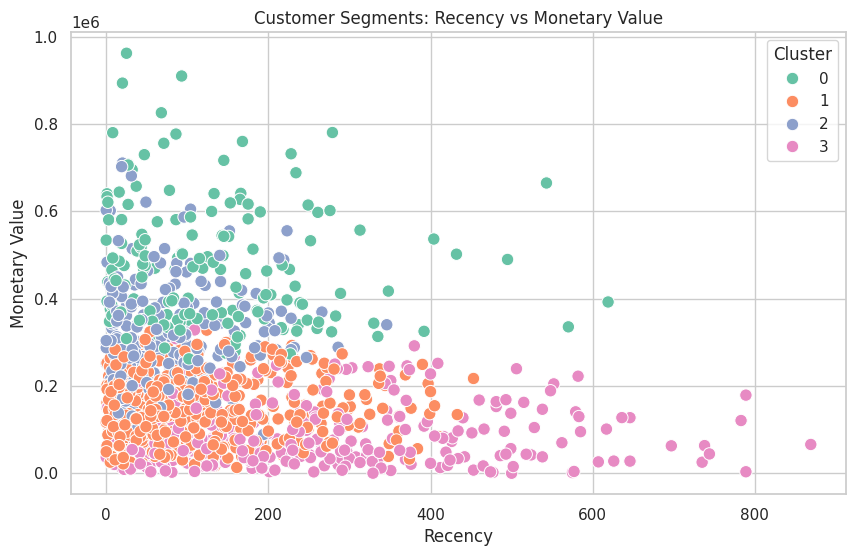

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customer_df,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("Customer Segments: Recency vs Monetary Value")
plt.xlabel("Recency")
plt.ylabel("Monetary Value")
plt.show()

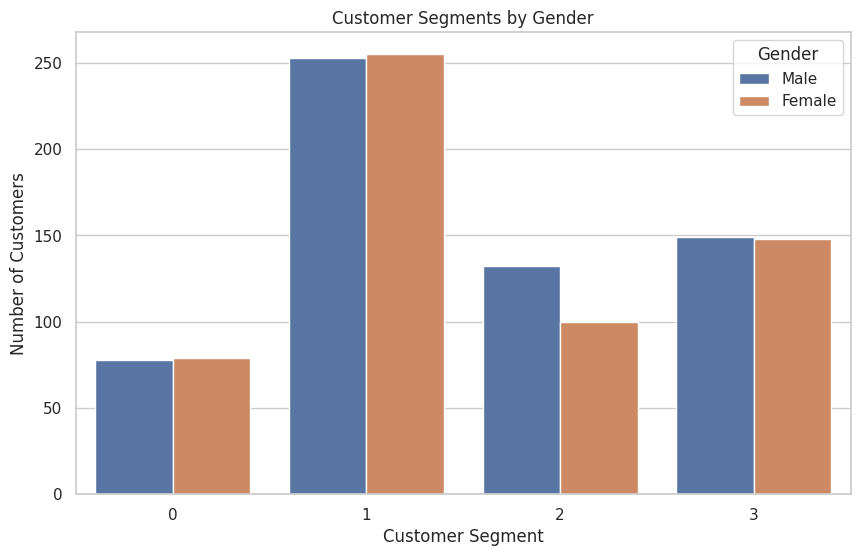

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=customer_df,
    x="Cluster",
    hue="Gender"
)

plt.title("Customer Segments by Gender")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.show()

Avg Recency
Avg Frequency
Avg Monetary
Avg Profit
High Frequency + High Monetary + Low Recency
→ VIP / High-Value Customers

High Frequency + Moderate Monetary
→ Loyal Customers

Low Frequency + Moderate Monetary
→ Occasional Customers

High Recency + Low Frequency + Low Monetary
→ At-Risk Customers

In [ ]:
customer_df.to_excel(
    "Customer_Segmentation_Final.xlsx",
    index=False
)

print("Final customer segmentation dataset exported successfully.")

Final customer segmentation dataset exported successfully.


# Customer Segment Interpretation

The K-Means algorithm generates numerical cluster labels. These labels are converted into business-friendly customer segments based on their purchasing behavior, including recency, frequency, monetary value, and profitability.

The objective is to translate machine-learning results into actionable business insights.

In [ ]:
cluster_profile = customer_df.groupby("Cluster").agg(
    Customers=("Customer ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Avg_Profit=("Total_Profit", "mean"),
    Avg_Order_Value=("Average_Order_Value", "mean"),
    Avg_Age=("Age", "mean")
).round(2)

display(cluster_profile)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Profit,Avg_Order_Value,Avg_Age
Cluster,,,,,,,
0,157,135.29,6.38,480020.53,69495.14,78251.54,41.61
1,508,111.23,6.33,149438.17,21569.94,24400.83,41.44
2,232,77.52,9.61,318947.13,46031.62,33744.37,41.31
3,297,253.14,3.54,92034.26,12982.51,26728.82,42.07
